# Markov Chain Monte Carlo (MCMC)
### Sampling from distributions you can't sample from directly

This notebook builds on the Markov Processes notebook. The stationary distribution and ergodicity concepts established there are the mathematical foundation everything here rests on.

The core problem: you have a probability distribution you can *evaluate* (up to a constant) but can't *sample from* directly. MCMC is a family of algorithms that solve this by constructing a Markov chain whose stationary distribution *is* the target distribution — then running the chain long enough to collect samples from it.

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy import stats

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'
YELLOW  = '#d29922'
PURPLE  = '#bc8cff'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("Ready.")

Ready.


## Part 1 — The problem: distributions you can evaluate but not sample

Suppose I want to sample from a probability distribution $p(x)$. There are three situations:

**Easy**: $p(x)$ is a standard distribution (Gaussian, Uniform, Beta...). NumPy has a sampler. Done.

**Harder**: $p(x)$ is some non-standard shape but I know the CDF. I can use inverse transform sampling.

**Hard**: $p(x)$ is a complicated function I can only evaluate pointwise — and often only up to a normalising constant:

$$p(x) = \frac{\tilde{p}(x)}{Z}, \quad Z = \int \tilde{p}(x)\, dx$$

Computing $Z$ might be analytically intractable or computationally prohibitive. In high dimensions, integration is extremely expensive. But I can still *evaluate* $\tilde{p}(x)$ for any given $x$ — I just can't normalise it.

This is the situation Bayesian inference lives in constantly:

$$p(\theta \mid \text{data}) = \frac{p(\text{data} \mid \theta)\, p(\theta)}{p(\text{data})}$$

The numerator is easy to evaluate for any $\theta$. The denominator $p(\text{data}) = \int p(\text{data}\mid\theta)\,p(\theta)\,d\theta$ is almost always intractable. So we know the posterior *shape* but not its *normalisation*.

MCMC's answer: we don't need $Z$. We only need the ratio $\tilde{p}(x') / \tilde{p}(x)$, which cancels the unknown constant.

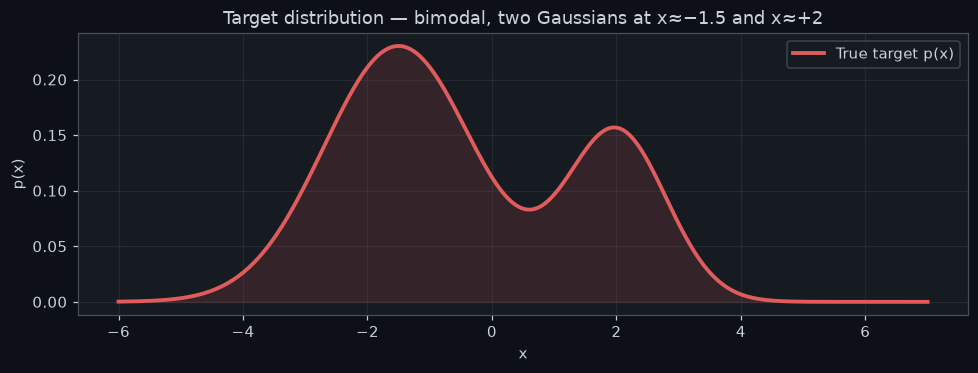

Z_true = 2.6067  (we pretend we don't know this)
We can evaluate target_unnorm(x) for any x, but we can't sample from it directly.


In [4]:
# ── The target distribution we'll use throughout ──────────────────────────────
# A bimodal distribution: mixture of two Gaussians
# Unnormalised — we pretend we don't know Z

def target_unnorm(x):
    """Unnormalised target: mixture of two Gaussians.
    We can EVALUATE this at any x but pretend we can't sample from it directly.
    """
    return 0.4 * np.exp(-0.5 * ((x - 2.0) / 0.8)**2) + \
           0.6 * np.exp(-0.5 * ((x + 1.5) / 1.2)**2)

# The true normalised version (for comparison only — MCMC won't use this)
x_range = np.linspace(-6, 7, 500)
Z_true = np.trapezoid(target_unnorm(x_range), x_range)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(x_range, target_unnorm(x_range) / Z_true,
        color=ACCENT, linewidth=2.5, label='True target p(x)')
ax.fill_between(x_range, target_unnorm(x_range) / Z_true,
                alpha=0.15, color=ACCENT)
ax.set_title('Target distribution — bimodal, two Gaussians at x≈−1.5 and x≈+2', color=TEXT)
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Z_true = {Z_true:.4f}  (we pretend we don't know this)")
print("We can evaluate target_unnorm(x) for any x, but we can't sample from it directly.")

## Part 2 — The key insight: detailed balance

From the Markov Processes notebook: a Markov chain has a stationary distribution $\pi$ if $\pi P = \pi$.

A *sufficient* condition for this (though not necessary) is **detailed balance**:

$$\pi(x) \cdot T(x' \mid x) = \pi(x') \cdot T(x \mid x')$$

This says: the probability flux from $x$ to $x'$ equals the flux from $x'$ to $x$. The chain is in equilibrium — it's reversible.

The MCMC insight: **if I can design a transition kernel $T$ that satisfies detailed balance with respect to my target $p$, then running the chain long enough will produce samples from $p$.**

I don't need to know $Z$ because detailed balance only involves ratios:

$$\frac{T(x' \mid x)}{T(x \mid x')} = \frac{\pi(x')}{\pi(x)} = \frac{\tilde{p}(x')}{\tilde{p}(x)}$$

The normalising constant cancels. This is the mathematical reason MCMC works without knowing $Z$.

## Part 3 — Metropolis-Hastings

Metropolis-Hastings (MH) is the foundational MCMC algorithm. It constructs a valid transition kernel by splitting each step into two parts:

**1. Propose**: from current position $x$, sample a candidate $x'$ from a *proposal distribution* $q(x' \mid x)$. This can be anything convenient — typically a Gaussian centred on $x$.

**2. Accept or reject**: compute the acceptance probability:

$$\alpha = \min\left(1,\ \frac{\tilde{p}(x')}{\tilde{p}(x)} \cdot \frac{q(x \mid x')}{q(x' \mid x)}\right)$$

Accept the proposal (move to $x'$) with probability $\alpha$. Otherwise stay at $x$.

The ratio $\tilde{p}(x') / \tilde{p}(x)$ is the **target ratio** — how much more probable is the proposed position than the current one?

The ratio $q(x \mid x') / q(x' \mid x)$ is the **proposal correction** — it corrects for any asymmetry in how we propose moves. For a symmetric proposal (Gaussian centred on current position), this ratio is 1 and drops out.

### Why does this satisfy detailed balance?

Consider a move from $x$ to $x'$ where $\tilde{p}(x') > \tilde{p}(x)$:
- $\alpha(x \to x')= 1$ — always accept moves uphill
- $\alpha(x' \to x) = \tilde{p}(x)/\tilde{p}(x') < 1$ — sometimes reject moves downhill

The chain spends more time in high-probability regions — which is exactly what sampling from $p$ requires.

In [5]:
def metropolis_hastings(target, n_samples, proposal_std=1.0, x_init=0.0):
    """
    Metropolis-Hastings with symmetric Gaussian proposal.
    
    target:       unnormalised target density function
    n_samples:    number of samples to collect
    proposal_std: standard deviation of the Gaussian proposal
    x_init:       starting position
    
    Returns: (samples, acceptance_rate)
    """
    samples  = np.zeros(n_samples)
    x        = x_init
    accepted = 0

    for i in range(n_samples):
        # Step 1: propose
        x_proposed = x + np.random.normal(0, proposal_std)

        # Step 2: acceptance probability
        # Symmetric proposal → correction ratio = 1
        # α = min(1, p̃(x') / p̃(x))
        p_current  = target(x)
        p_proposed = target(x_proposed)

        alpha = min(1.0, p_proposed / (p_current + 1e-300))

        # Step 3: accept or reject
        if np.random.uniform() < alpha:
            x = x_proposed
            accepted += 1

        samples[i] = x

    return samples, accepted / n_samples


# Run MH
n_samples = 50_000
samples_mh, accept_rate = metropolis_hastings(
    target_unnorm, n_samples=n_samples, proposal_std=1.5, x_init=0.0
)

print(f"Samples collected:  {n_samples:,}")
print(f"Acceptance rate:    {accept_rate:.1%}")
print(f"Sample mean:        {samples_mh.mean():.4f}")
print(f"Sample std:         {samples_mh.std():.4f}")

Samples collected:  50,000
Acceptance rate:    71.7%
Sample mean:        -0.3935
Sample std:         1.9428


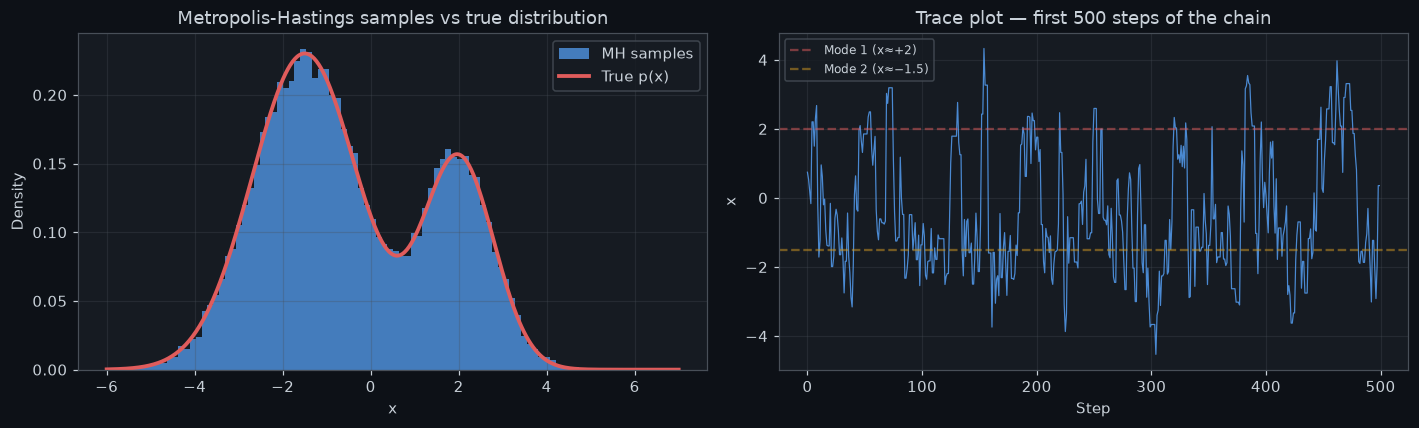

In [6]:
# ── Compare samples to true target ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(samples_mh, bins=80, density=True, color=BLUE, alpha=0.7, label='MH samples')
ax.plot(x_range, target_unnorm(x_range) / Z_true,
        color=ACCENT, linewidth=2.5, label='True p(x)')
ax.set_title('Metropolis-Hastings samples vs true distribution', color=TEXT)
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True)

# Trace plot: the chain's path through x over time
ax = axes[1]
ax.plot(samples_mh[:500], color=BLUE, linewidth=0.8, alpha=0.8)
ax.axhline(2.0,  color=ACCENT,  linestyle='--', alpha=0.5, label='Mode 1 (x≈+2)')
ax.axhline(-1.5, color=YELLOW, linestyle='--', alpha=0.5, label='Mode 2 (x≈−1.5)')
ax.set_title('Trace plot — first 500 steps of the chain', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('x')
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

## Part 4 — Burn-in and the transient phase

The chain starts at an arbitrary position $x_0$. Early samples reflect where we started, not the target distribution. This initial transient period is called **burn-in**.

Standard practice: discard the first $B$ samples and only use samples after the chain has reached its stationary distribution. How long is burn-in? It depends on the chain's **mixing time** — how quickly it forgets its starting point.

A chain that mixes slowly:
- Gets stuck in local regions for long periods
- Takes many steps to traverse the full support of $p$
- Requires longer burn-in and more total samples for accurate estimates

The trace plot above is the standard diagnostic: does the chain look like it's moving freely across the support, or does it get stuck?

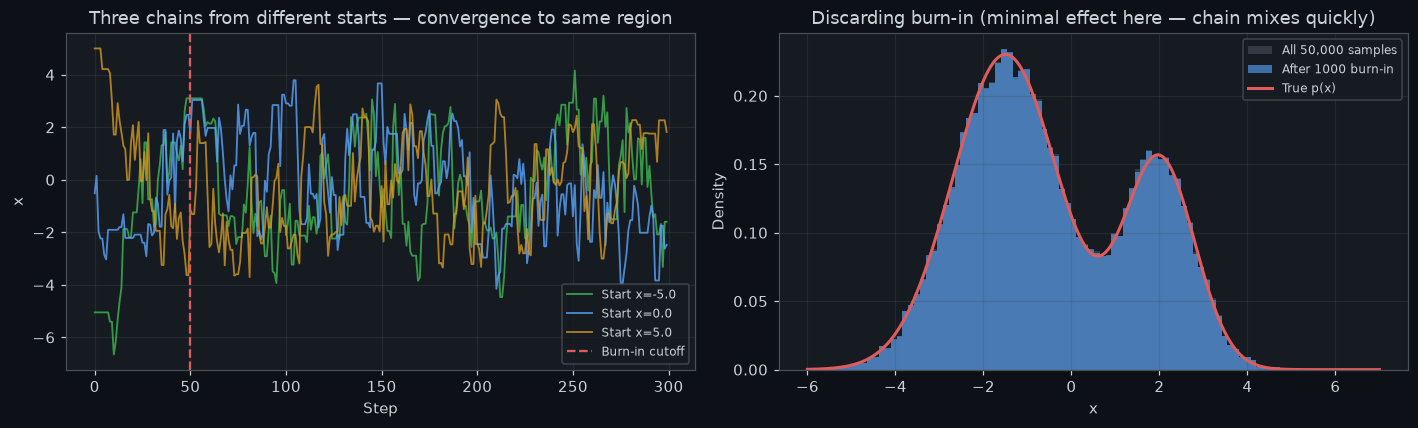

In [7]:
# ── Effect of starting position — burn-in ─────────────────────────────────────
starting_positions = [-5.0, 0.0, 5.0]
colors_start = [GREEN, BLUE, YELLOW]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for x0, col in zip(starting_positions, colors_start):
    samps, _ = metropolis_hastings(target_unnorm, n_samples=300,
                                    proposal_std=1.5, x_init=x0)
    ax.plot(samps, color=col, linewidth=1.2, alpha=0.8, label=f'Start x={x0}')

ax.axvline(50, color=ACCENT, linestyle='--', linewidth=1.5, label='Burn-in cutoff')
ax.set_title('Three chains from different starts — convergence to same region', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('x')
ax.legend(fontsize=8)
ax.grid(True)

# Effect of discarding burn-in
ax = axes[1]
burn_in = 1000
samples_with_burnin    = samples_mh
samples_without_burnin = samples_mh[burn_in:]

ax.hist(samples_with_burnin,    bins=80, density=True,
        color=MUTED, alpha=0.6, label=f'All {n_samples:,} samples')
ax.hist(samples_without_burnin, bins=80, density=True,
        color=BLUE,  alpha=0.6, label=f'After {burn_in} burn-in')
ax.plot(x_range, target_unnorm(x_range) / Z_true,
        color=ACCENT, linewidth=2, label='True p(x)')
ax.set_title('Discarding burn-in (minimal effect here — chain mixes quickly)', color=TEXT)
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

## Part 5 — The proposal distribution: the critical tuning parameter

The proposal distribution $q(x' \mid x)$ is the one thing the algorithm designer controls. The choice of proposal standard deviation has a dramatic effect on chain behaviour.

**Too small**: proposals are tiny steps. Almost all are accepted (high acceptance rate) but the chain barely moves. It takes an enormous number of steps to explore the full distribution. The samples are highly correlated — effectively you have far fewer *independent* samples than the count suggests.

**Too large**: proposals are wild jumps, usually landing in low-probability regions. Almost all are rejected (low acceptance rate). The chain stays stuck at the same point for many steps.

**Just right**: the chain moves efficiently across the target distribution, exploring both modes regularly. For a Gaussian target in $d$ dimensions, the theoretical optimal acceptance rate is approximately **23.4%**. In practice, targeting 20–40% acceptance is the standard heuristic.

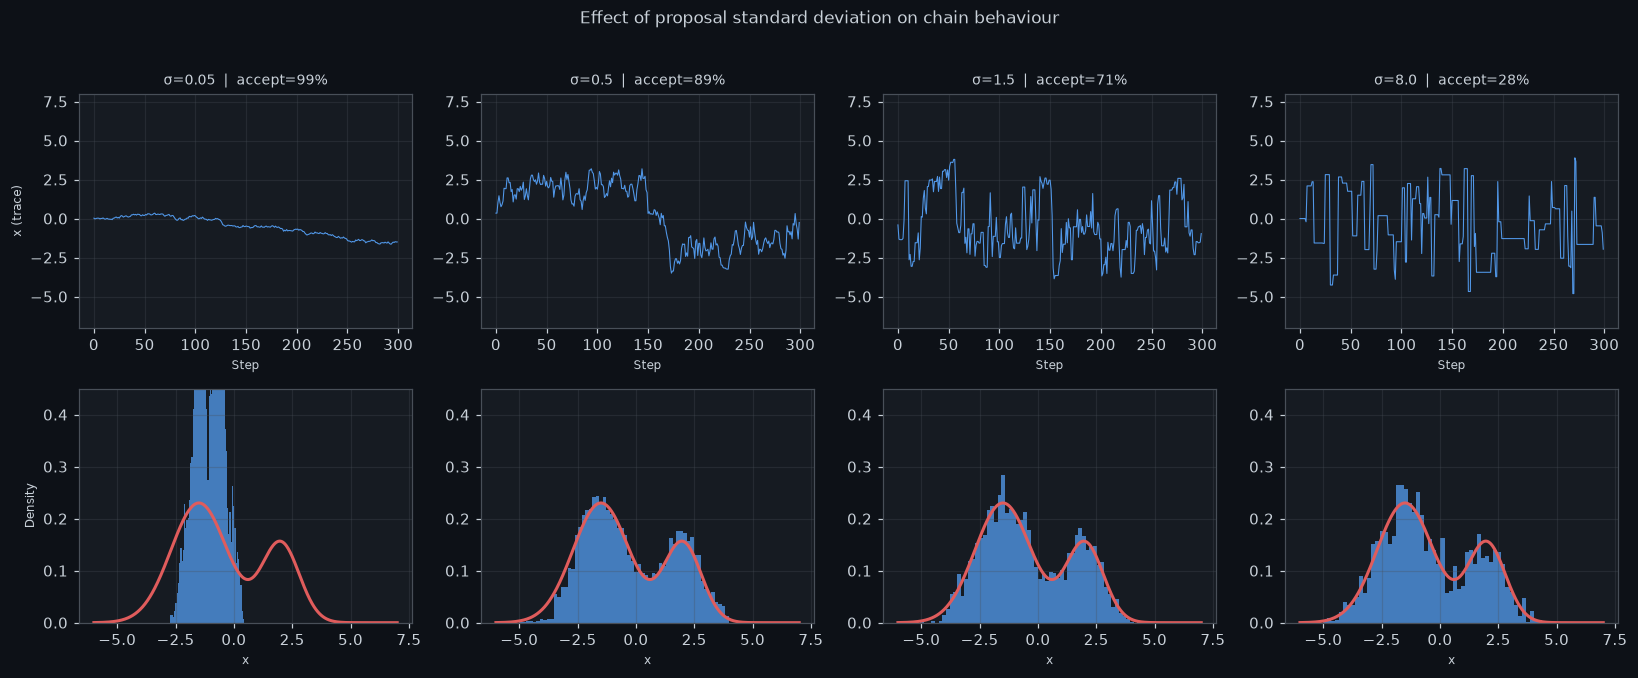

σ=0.05: high acceptance, tiny steps — chain barely explores
σ=0.5:  reasonable — but may not jump between modes reliably
σ=1.5:  good mixing — both modes found, sensible acceptance rate
σ=8.0:  low acceptance — chain mostly stuck, poor coverage


In [8]:
# ── Proposal size effect ───────────────────────────────────────────────────────
proposal_stds = [0.05, 0.5, 1.5, 8.0]
n_diag = 5000

fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for col, std in enumerate(proposal_stds):
    samps, rate = metropolis_hastings(target_unnorm, n_diag, proposal_std=std)

    # Trace plot
    ax = axes[0, col]
    ax.plot(samps[:300], color=BLUE, linewidth=0.7, alpha=0.9)
    ax.set_title(f'σ={std}  |  accept={rate:.0%}', color=TEXT, fontsize=9)
    ax.set_ylim(-7, 8)
    ax.set_xlabel('Step', fontsize=8)
    if col == 0:
        ax.set_ylabel('x (trace)', fontsize=8)
    ax.grid(True)

    # Histogram vs truth
    ax = axes[1, col]
    ax.hist(samps, bins=60, density=True, color=BLUE, alpha=0.7)
    ax.plot(x_range, target_unnorm(x_range) / Z_true, color=ACCENT, linewidth=2)
    ax.set_ylim(0, 0.45)
    ax.set_xlabel('x', fontsize=8)
    if col == 0:
        ax.set_ylabel('Density', fontsize=8)
    ax.grid(True)

fig.suptitle('Effect of proposal standard deviation on chain behaviour',
             color=TEXT, fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("σ=0.05: high acceptance, tiny steps — chain barely explores")
print("σ=0.5:  reasonable — but may not jump between modes reliably")
print("σ=1.5:  good mixing — both modes found, sensible acceptance rate")
print("σ=8.0:  low acceptance — chain mostly stuck, poor coverage")

## Part 6 — Autocorrelation and effective sample size

MCMC samples are not independent — consecutive samples are correlated because each one is derived from the previous. This matters because statistical estimators assume independence.

**Autocorrelation** at lag $k$ measures how similar samples $t$ and $t+k$ are:

$$\rho_k = \frac{\text{Cov}(x_t, x_{t+k})}{\text{Var}(x_t)}$$

High autocorrelation at lag 1 means consecutive samples are nearly identical — the chain is mixing slowly.

**Effective Sample Size (ESS)** converts the correlated sample count into an equivalent number of independent samples:

$$\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{\infty} \rho_k}$$

If ESS = 500 from 10,000 samples, you effectively have 500 independent data points despite collecting 10,000. The ratio ESS/N is the sampling efficiency.

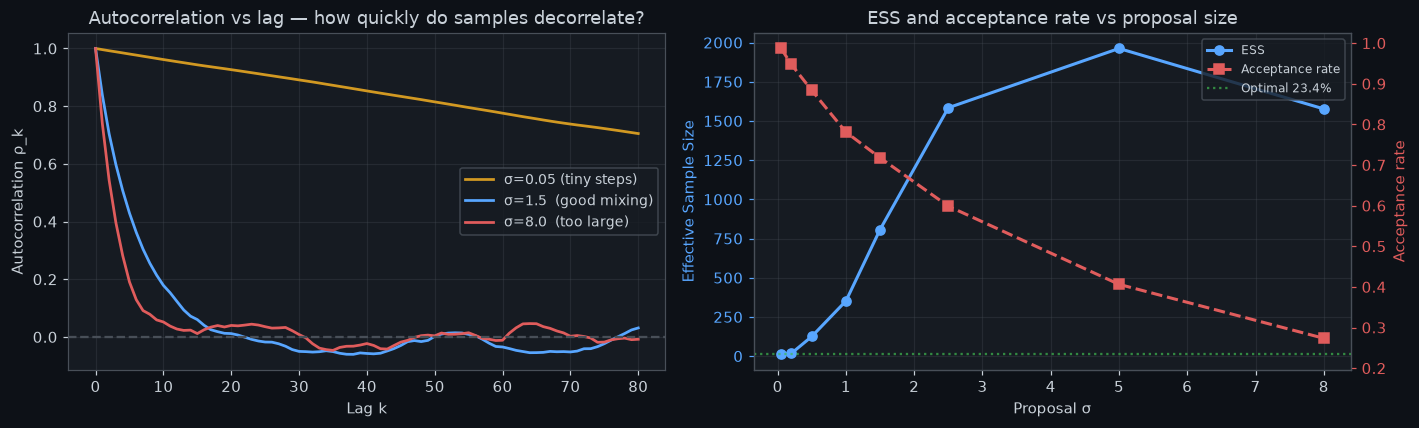

In [9]:
def autocorrelation(samples, max_lag=100):
    """Compute autocorrelation at lags 0..max_lag."""
    n    = len(samples)
    mean = samples.mean()
    var  = samples.var()
    acf  = []
    for k in range(max_lag + 1):
        cov = np.mean((samples[:n-k] - mean) * (samples[k:] - mean))
        acf.append(cov / var)
    return np.array(acf)

def effective_sample_size(samples, max_lag=500):
    """ESS via integrated autocorrelation time."""
    acf = autocorrelation(samples, max_lag)
    # Sum until autocorrelation drops below 0 (practical truncation)
    cutoff = np.argmax(acf[1:] < 0) + 1
    cutoff = cutoff if cutoff > 1 else max_lag
    iat = 1 + 2 * acf[1:cutoff].sum()   # integrated autocorrelation time
    return len(samples) / iat

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for std, col, label in [
    (0.05, YELLOW, 'σ=0.05 (tiny steps)'),
    (1.5,  BLUE,   'σ=1.5  (good mixing)'),
    (8.0,  ACCENT, 'σ=8.0  (too large)'),
]:
    samps, _ = metropolis_hastings(target_unnorm, 5000, proposal_std=std)
    acf = autocorrelation(samps, max_lag=80)
    ax.plot(acf, color=col, linewidth=1.8, label=label)

ax.axhline(0, color=MUTED, linestyle='--')
ax.set_title('Autocorrelation vs lag — how quickly do samples decorrelate?', color=TEXT)
ax.set_xlabel('Lag k')
ax.set_ylabel('Autocorrelation ρ_k')
ax.legend(fontsize=9)
ax.grid(True)

# ESS comparison
ax = axes[1]
stds = [0.05, 0.2, 0.5, 1.0, 1.5, 2.5, 5.0, 8.0]
ess_vals = []
accept_vals = []
for std in stds:
    samps, rate = metropolis_hastings(target_unnorm, 10000, proposal_std=std)
    ess_vals.append(effective_sample_size(samps))
    accept_vals.append(rate)

ax2 = ax.twinx()
ax.plot(stds, ess_vals,    color=BLUE,   marker='o', linewidth=2, label='ESS')
ax2.plot(stds, accept_vals, color=ACCENT, marker='s', linewidth=2,
         linestyle='--', label='Acceptance rate')
ax2.axhline(0.234, color=GREEN, linestyle=':', alpha=0.7, label='Optimal 23.4%')

ax.set_title('ESS and acceptance rate vs proposal size', color=TEXT)
ax.set_xlabel('Proposal σ')
ax.set_ylabel('Effective Sample Size', color=BLUE)
ax2.set_ylabel('Acceptance rate', color=ACCENT)
ax.tick_params(axis='y', colors=BLUE)
ax2.tick_params(axis='y', colors=ACCENT)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.show()

## Part 7 — Gibbs Sampling

Metropolis-Hastings proposes moves in the full parameter space. In high dimensions, good proposals become very hard to design — the acceptance rate collapses because random jumps in many dimensions almost always land in low-probability regions.

**Gibbs sampling** sidesteps this by updating one dimension at a time, conditioning on all others:

$$x_i^{(t+1)} \sim p(x_i \mid x_1^{(t+1)}, \ldots, x_{i-1}^{(t+1)}, x_{i+1}^{(t)}, \ldots, x_d^{(t)})$$

Each conditional $p(x_i \mid \mathbf{x}_{-i})$ is a 1D distribution — often standard and easy to sample from exactly. Gibbs sampling has **acceptance rate 1.0** by construction: every proposal is accepted because we're sampling exactly from the conditional.

The catch: if dimensions are strongly correlated, Gibbs mixing is slow — updating one dimension while holding others fixed makes only tiny effective moves through the joint distribution.

Gibbs is a special case of MH where the proposal is the exact conditional — the acceptance ratio works out to exactly 1.

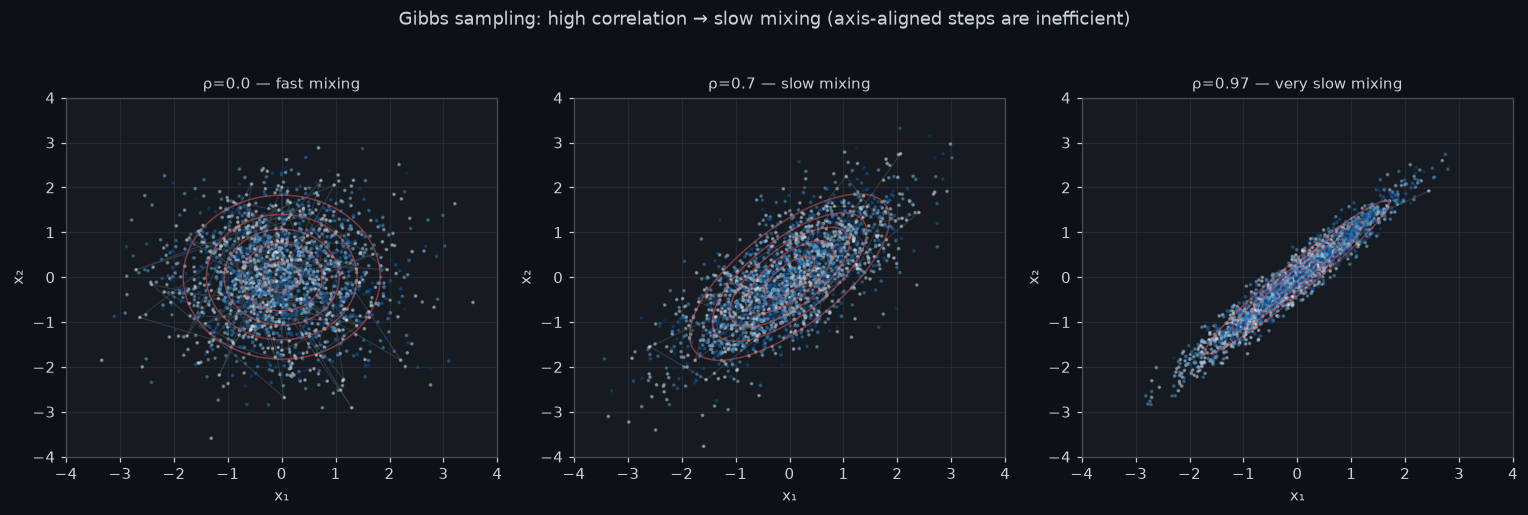

ρ=0.00: uncorrelated — Gibbs mixes immediately, steps span full range
ρ=0.70: moderate correlation — takes longer to traverse the diagonal
ρ=0.97: strong correlation — chain crawls along the thin diagonal, very slow


In [10]:
# ── Gibbs sampling on a 2D correlated Gaussian ────────────────────────────────
# Target: bivariate Gaussian with correlation ρ
# Conditionals are available analytically for a Gaussian

def gibbs_bivariate_gaussian(rho, n_samples, x_init=(0.0, 0.0)):
    """
    Gibbs sampler for bivariate Gaussian N(0, [[1,ρ],[ρ,1]]).
    Conditional distributions:
      p(x1 | x2) = N(ρ·x2, 1-ρ²)
      p(x2 | x1) = N(ρ·x1, 1-ρ²)
    """
    samples = np.zeros((n_samples, 2))
    x1, x2  = x_init
    cond_std = np.sqrt(1 - rho**2)

    for i in range(n_samples):
        # Update x1 | x2
        x1 = np.random.normal(rho * x2, cond_std)
        # Update x2 | x1
        x2 = np.random.normal(rho * x1, cond_std)
        samples[i] = [x1, x2]

    return samples


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, rho in zip(axes, [0.0, 0.7, 0.97]):
    samps = gibbs_bivariate_gaussian(rho, n_samples=2000, x_init=(3.0, 3.0))

    # Show trajectory of first 100 steps
    ax.plot(samps[:100, 0], samps[:100, 1],
            color=MUTED, linewidth=0.7, alpha=0.6, zorder=1)
    ax.scatter(samps[:, 0], samps[:, 1],
               c=np.arange(len(samps)), cmap='Blues',
               s=2, alpha=0.4, zorder=2)

    # True contours
    cov = np.array([[1, rho], [rho, 1]])
    g   = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(g, g)
    pos  = np.dstack((X, Y))
    rv   = stats.multivariate_normal(mean=[0,0], cov=cov)
    ax.contour(X, Y, rv.pdf(pos), levels=5, colors=[ACCENT], alpha=0.5, linewidths=1)

    ax.set_title(f'ρ={rho} — {"fast" if rho < 0.5 else "slow" if rho < 0.9 else "very slow"} mixing',
                 color=TEXT, fontsize=10)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True)

fig.suptitle('Gibbs sampling: high correlation → slow mixing (axis-aligned steps are inefficient)',
             color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

print("ρ=0.00: uncorrelated — Gibbs mixes immediately, steps span full range")
print("ρ=0.70: moderate correlation — takes longer to traverse the diagonal")
print("ρ=0.97: strong correlation — chain crawls along the thin diagonal, very slow")

## Part 8 — Why MCMC matters: a Bayesian inference example

I want to make this concrete. The abstract problem was: posterior distributions are intractable. Here's a real instance.

**Setup**: I observe some data that I believe was generated from a Gaussian with unknown mean $\mu$ and unknown precision $\tau = 1/\sigma^2$. I have prior beliefs about $\mu$ and $\tau$. I want the posterior $p(\mu, \tau \mid \text{data})$.

The posterior is proportional to:

$$p(\mu, \tau \mid \mathbf{x}) \propto p(\mathbf{x} \mid \mu, \tau) \cdot p(\mu) \cdot p(\tau)$$

$$= \prod_i \mathcal{N}(x_i \mid \mu, 1/\tau) \cdot \mathcal{N}(\mu \mid 0, 1) \cdot \text{Gamma}(\tau \mid 2, 1)$$

I can evaluate the right-hand side for any $\mu, \tau$. I can't integrate over it analytically (unless I use conjugate priors — but pretend I can't). MCMC lets me draw samples from the posterior without knowing the normalising constant.

In [11]:
# ── Bayesian inference via MH ──────────────────────────────────────────────────
# True parameters
TRUE_MU  = 3.5
TRUE_STD = 1.2

# Observed data
np.random.seed(7)
n_obs = 20
data  = np.random.normal(TRUE_MU, TRUE_STD, n_obs)

def log_posterior(mu, tau):
    """Log unnormalised posterior for (mu, tau).
    Working in log space avoids numerical underflow.
    """
    if tau <= 0:
        return -np.inf

    # Log likelihood: sum of log N(x_i | mu, 1/tau)
    log_lik = 0.5 * n_obs * np.log(tau) - \
              0.5 * tau * np.sum((data - mu)**2)

    # Log prior: mu ~ N(0,1), tau ~ Gamma(2,1)
    log_prior_mu  = -0.5 * mu**2
    log_prior_tau = 1.0 * np.log(tau) - tau   # log Gamma(2,1) up to constant

    return log_lik + log_prior_mu + log_prior_tau

def mh_2d(log_target, n_samples, proposal_std, init):
    """MH in 2D, working in log space for numerical stability."""
    samples  = np.zeros((n_samples, 2))
    x        = np.array(init, dtype=float)
    lp_curr  = log_target(*x)
    accepted = 0

    for i in range(n_samples):
        x_prop = x + np.random.normal(0, proposal_std, 2)
        lp_prop = log_target(*x_prop)

        # Log acceptance ratio — equivalent to min(1, p'/p) in log space
        log_alpha = lp_prop - lp_curr
        if np.log(np.random.uniform()) < log_alpha:
            x       = x_prop
            lp_curr = lp_prop
            accepted += 1

        samples[i] = x

    return samples, accepted / n_samples


# Run inference
post_samples, ar = mh_2d(
    log_posterior, n_samples=30_000,
    proposal_std=np.array([0.15, 0.15]),
    init=[0.0, 1.0]
)

burn = 2000
post_mu  = post_samples[burn:, 0]
post_tau = post_samples[burn:, 1]

print(f"Acceptance rate: {ar:.1%}")
print(f"\nPosterior estimates:")
print(f"  μ:  mean={post_mu.mean():.3f}  std={post_mu.std():.3f}  (true: {TRUE_MU})")
print(f"  τ:  mean={post_tau.mean():.3f}  std={post_tau.std():.3f}  (true: {1/TRUE_STD**2:.3f})")
print(f"  σ:  mean={np.mean(1/np.sqrt(post_tau)):.3f}  (true: {TRUE_STD})")

Acceptance rate: 70.8%

Posterior estimates:
  μ:  mean=3.205  std=0.225  (true: 3.5)
  τ:  mean=1.039  std=0.321  (true: 0.694)
  σ:  mean=1.018  (true: 1.2)


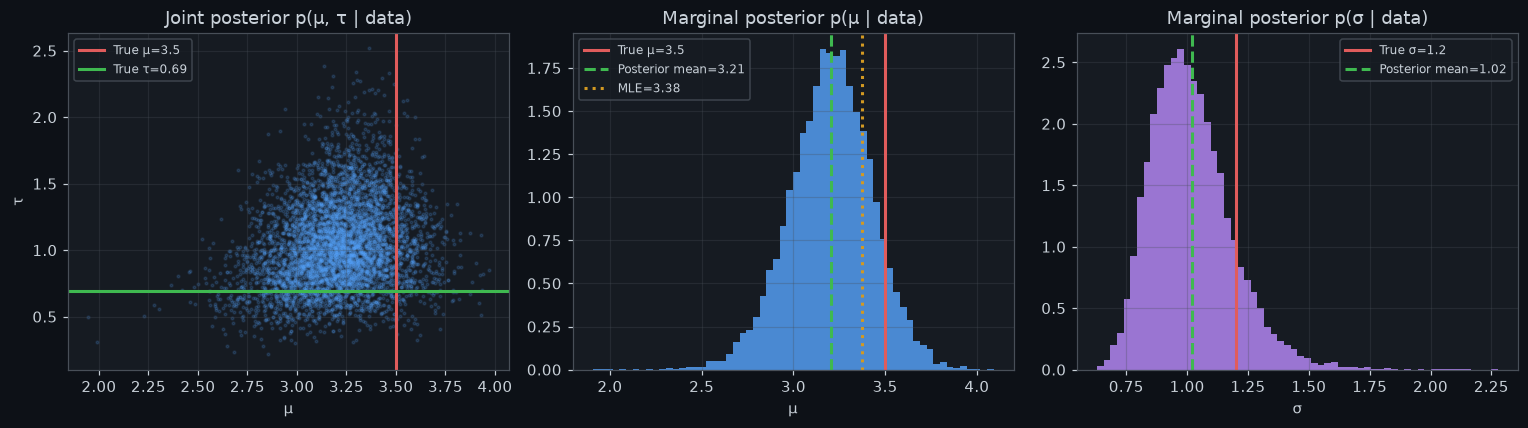


The posterior correctly recovers the true parameters.
The prior on μ pulls the estimate slightly toward 0 (shrinkage).
With only 20 observations, the posterior is wide — appropriate uncertainty.


In [12]:
# ── Visualise the posterior ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Joint posterior
ax = axes[0]
ax.scatter(post_mu[::5], post_tau[::5], alpha=0.15, s=3, color=BLUE)
ax.axvline(TRUE_MU,        color=ACCENT, linewidth=2, label=f'True μ={TRUE_MU}')
ax.axhline(1/TRUE_STD**2,  color=GREEN,  linewidth=2, label=f'True τ={1/TRUE_STD**2:.2f}')
ax.set_xlabel('μ')
ax.set_ylabel('τ')
ax.set_title('Joint posterior p(μ, τ | data)', color=TEXT)
ax.legend(fontsize=8)
ax.grid(True)

# Marginal posterior for μ
ax = axes[1]
ax.hist(post_mu, bins=60, density=True, color=BLUE, alpha=0.8)
ax.axvline(TRUE_MU,       color=ACCENT, linewidth=2, label=f'True μ={TRUE_MU}')
ax.axvline(post_mu.mean(), color=GREEN,  linewidth=2, linestyle='--',
           label=f'Posterior mean={post_mu.mean():.2f}')
ax.axvline(data.mean(),    color=YELLOW, linewidth=2, linestyle=':',
           label=f'MLE={data.mean():.2f}')
ax.set_xlabel('μ')
ax.set_title('Marginal posterior p(μ | data)', color=TEXT)
ax.legend(fontsize=8)
ax.grid(True)

# Marginal posterior for σ (converted from τ)
ax = axes[2]
post_sigma = 1 / np.sqrt(post_tau)
ax.hist(post_sigma, bins=60, density=True, color=PURPLE, alpha=0.8)
ax.axvline(TRUE_STD,          color=ACCENT, linewidth=2, label=f'True σ={TRUE_STD}')
ax.axvline(post_sigma.mean(), color=GREEN,  linewidth=2, linestyle='--',
           label=f'Posterior mean={post_sigma.mean():.2f}')
ax.set_xlabel('σ')
ax.set_title('Marginal posterior p(σ | data)', color=TEXT)
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

print("\nThe posterior correctly recovers the true parameters.")
print("The prior on μ pulls the estimate slightly toward 0 (shrinkage).")
print("With only 20 observations, the posterior is wide — appropriate uncertainty.")

## Part 9 — MCMC in the ML context

MCMC shows up throughout ML, often in places that aren't obviously Bayesian:

**Bayesian neural networks**: instead of a single set of weights $\theta$, maintain a distribution over weights $p(\theta \mid \text{data})$. Predictions average over the posterior — natural uncertainty quantification. MCMC (or variational inference as an approximation) samples from this posterior.

**Diffusion models**: the forward process (adding noise) is a Markov chain. The reverse process (denoising) is also learned as a Markov chain. DDPM (Denoising Diffusion Probabilistic Models) can be interpreted through the lens of score matching and Langevin dynamics — a continuous-time version of MCMC.

**Gibbs sampling in topic models**: Latent Dirichlet Allocation (LDA) is classically trained with collapsed Gibbs sampling — iteratively resampling topic assignments for each word given all other assignments.

**RLHF**: the reward model training set is effectively a sample from human preference distribution. The KL penalty in the RLHF objective keeps the policy close to the SFT prior — this is related to the same ideas as keeping an MCMC chain close to a reference distribution to avoid mode collapse.

**Hamiltonian Monte Carlo (HMC)**: the modern workhorse for Bayesian inference in tools like Stan and PyMC. Instead of random-walk proposals, it uses gradient information to propose moves along the geometry of the target. Much more efficient in high dimensions — but that's a notebook in its own right.

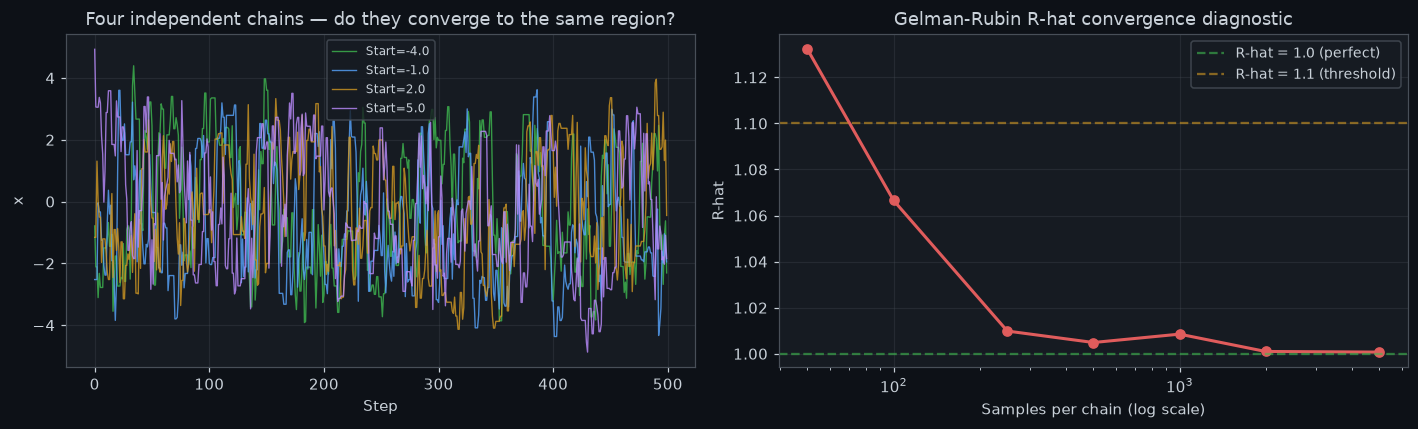

R-hat values at each checkpoint:
     50 samples: R-hat = 1.1322  ✗ not yet
    100 samples: R-hat = 1.0666  ✓ converged
    250 samples: R-hat = 1.0099  ✓ converged
    500 samples: R-hat = 1.0049  ✓ converged
   1000 samples: R-hat = 1.0085  ✓ converged
   2000 samples: R-hat = 1.0010  ✓ converged
   5000 samples: R-hat = 1.0007  ✓ converged


In [13]:
# ── MCMC diagnostic: the Gelman-Rubin R-hat statistic ─────────────────────────
# Run multiple chains and check they've converged to the same distribution.
# R-hat ≈ 1.0 means chains agree. R-hat > 1.1 suggests non-convergence.

def r_hat(chains):
    """
    Gelman-Rubin convergence diagnostic.
    chains: list of 1D sample arrays (each from an independent chain)
    R-hat close to 1.0 → convergence. R-hat > 1.1 → not yet converged.
    """
    m = len(chains)          # number of chains
    n = len(chains[0])       # samples per chain

    chain_means = np.array([c.mean() for c in chains])
    grand_mean  = chain_means.mean()

    # Between-chain variance
    B = n / (m - 1) * np.sum((chain_means - grand_mean)**2)

    # Within-chain variance
    W = np.mean([c.var(ddof=1) for c in chains])

    # Pooled variance estimate
    var_hat = (1 - 1/n) * W + B / n

    return np.sqrt(var_hat / W)


# Run 4 independent chains from different starting points
starts  = [-4.0, -1.0, 2.0, 5.0]
n_chain = 5000
chains  = []
for x0 in starts:
    s, _ = metropolis_hastings(target_unnorm, n_chain, proposal_std=1.5, x_init=x0)
    chains.append(s)

# R-hat at different points in the chain
checkpoints = [50, 100, 250, 500, 1000, 2000, 5000]
rhats = [r_hat([c[:cp] for c in chains]) for cp in checkpoints]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for c, x0, col in zip(chains, starts, [GREEN, BLUE, YELLOW, PURPLE]):
    ax.plot(c[:500], color=col, linewidth=0.9, alpha=0.8, label=f'Start={x0}')
ax.set_title('Four independent chains — do they converge to the same region?', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('x')
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
ax.semilogx(checkpoints, rhats, color=ACCENT, marker='o', linewidth=2)
ax.axhline(1.0, color=GREEN,  linestyle='--', alpha=0.6, label='R-hat = 1.0 (perfect)')
ax.axhline(1.1, color=YELLOW, linestyle='--', alpha=0.6, label='R-hat = 1.1 (threshold)')
ax.set_title('Gelman-Rubin R-hat convergence diagnostic', color=TEXT)
ax.set_xlabel('Samples per chain (log scale)')
ax.set_ylabel('R-hat')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

print("R-hat values at each checkpoint:")
for cp, rh in zip(checkpoints, rhats):
    status = '✓ converged' if rh < 1.1 else '✗ not yet'
    print(f"  {cp:5d} samples: R-hat = {rh:.4f}  {status}")

## Summary

| Concept | What it is |
|---------|------------|
| **The problem** | Can evaluate $\tilde{p}(x)$ but can't sample from $p(x)$ — normaliser $Z$ unknown |
| **Detailed balance** | $\pi(x)T(x'\|x) = \pi(x')T(x\|x')$ — sufficient for $\pi$ to be stationary |
| **Metropolis-Hastings** | Propose from $q(x'\|x)$, accept with $\alpha = \min(1, \tilde{p}(x')/\tilde{p}(x) \cdot q(x\|x')/q(x'\|x))$ |
| **Burn-in** | Discard early samples taken before chain reaches stationarity |
| **Proposal tuning** | Too small → slow exploration; too large → high rejection. Target ~23% acceptance |
| **Autocorrelation** | Consecutive samples are correlated; reduces effective information per sample |
| **ESS** | $N / (1 + 2\sum_k \rho_k)$ — equivalent number of independent samples |
| **Gibbs sampling** | Update one dimension at a time from exact conditional; acceptance rate = 1 |
| **R-hat** | Multi-chain convergence diagnostic; R-hat < 1.1 indicates convergence |

---

### The key equations

**Detailed balance:**
$$\boxed{\pi(x)\, T(x' \mid x) = \pi(x')\, T(x \mid x')}$$

**MH acceptance probability:**
$$\boxed{\alpha = \min\!\left(1,\ \frac{\tilde{p}(x')}{\tilde{p}(x)} \cdot \frac{q(x \mid x')}{q(x' \mid x)}\right)}$$

**Effective Sample Size:**
$$\boxed{\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{\infty} \rho_k}}$$

---

## Things to try

- Change `target_unnorm` to a distribution with three modes — does MH find all three? Try different proposal sizes.
- Set `proposal_std=0.01` — how many samples before the second mode is found?
- Add a third parameter to the Bayesian inference example — does the acceptance rate drop? Why?
- Try starting all four Gelman-Rubin chains from the *same* point — what happens to R-hat? Why is that a problem?
- Implement a simple adaptive MH: adjust `proposal_std` during burn-in to target 23% acceptance, then freeze it.